# Olist 판매자 유형 클러스터링 v3

## 목적
Olist 셀러의 매출 시계열을 분석해 4개 유형으로 분류하고, 합성 코호트의 분산 파라미터로 사용한다.

## v2 → v3 개선점
1. **활성 구간 ≥ 12개월 필터**: 1년 미만 셀러는 시계열 패턴 추출이 불가능 → 651명으로 압축
2. **`seasonality_strength` 재정의**: 기존 std-ratio 방식이 거의 모든 셀러에서 1.0에 수렴 → **ACF lag-12** (12개월 자기상관)으로 교체
3. **K=3,4,5,6 silhouette 비교** 후 최적 K 선택
4. **임계 기반 라벨링**: 무조건 4개 라벨을 강제하지 않고, 임계 미달 클러스터는 "기타/쇠퇴형"으로 빠짐

## 산출물
- `seller_features_v3.csv` — 새 피처 + 라벨
- `clustering_v3_diagnostics.png` — 진단 시각화

## 0. 환경 셋업

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

DATA = Path('/Users/eoseungyun/Desktop/project/SW_Capstone/Project/Data')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

MIN_ACTIVE_MONTHS = 12

color_map = {
    '안정형 (Stable)': 'steelblue',
    '성장형 (Growth)': 'mediumseagreen',
    '계절형 (Seasonal)': 'darkorange',
    '불안정형 (Volatile)': 'crimson',
    '쇠퇴형 (Decline)': 'gray',
}
print('환경 셋업 완료')

환경 셋업 완료


## 1. 데이터 로드

**`monthly_seller_revenue.csv`**: Olist 원본 데이터(99,441 주문)를 셀러×월 단위로 집계한 결과.

In [2]:
monthly = pd.read_csv(DATA / 'monthly_seller_revenue.csv')
monthly['ym'] = pd.to_datetime(monthly['year_month'])

n_total = monthly['seller_id'].nunique()
print(f'전체 행 수: {len(monthly):,}')
print(f'전체 셀러: {n_total:,}')
print(f'기간: {monthly["ym"].min().date()} ~ {monthly["ym"].max().date()}')
print(f'\n샘플:')
monthly.head()

전체 행 수: 71,280
전체 셀러: 2,970
기간: 2016-09-01 ~ 2018-08-01

샘플:


,seller_id,year_month,monthly_revenue,monthly_orders,active_days,year_month_dt,ym
0,0015a82c2db000af6aaaf3ae2ecb0532,2016-09,0.0,0.0,0,2016-09-01,2016-09-01
1,0015a82c2db000af6aaaf3ae2ecb0532,2016-10,0.0,0.0,0,2016-10-01,2016-10-01
2,0015a82c2db000af6aaaf3ae2ecb0532,2016-11,0.0,0.0,0,2016-11-01,2016-11-01
3,0015a82c2db000af6aaaf3ae2ecb0532,2016-12,0.0,0.0,0,2016-12-01,2016-12-01
4,0015a82c2db000af6aaaf3ae2ecb0532,2017-01,0.0,0.0,0,2017-01-01,2017-01-01


## 2. 활성 기간 분포 — 12개월 필터의 정당화

각 셀러의 "활성 구간 길이" (첫 매출 ~ 마지막 매출 사이 개월수)를 분석. ACF lag-12로 계절성을 추출하려면 최소 12개월이 필요.

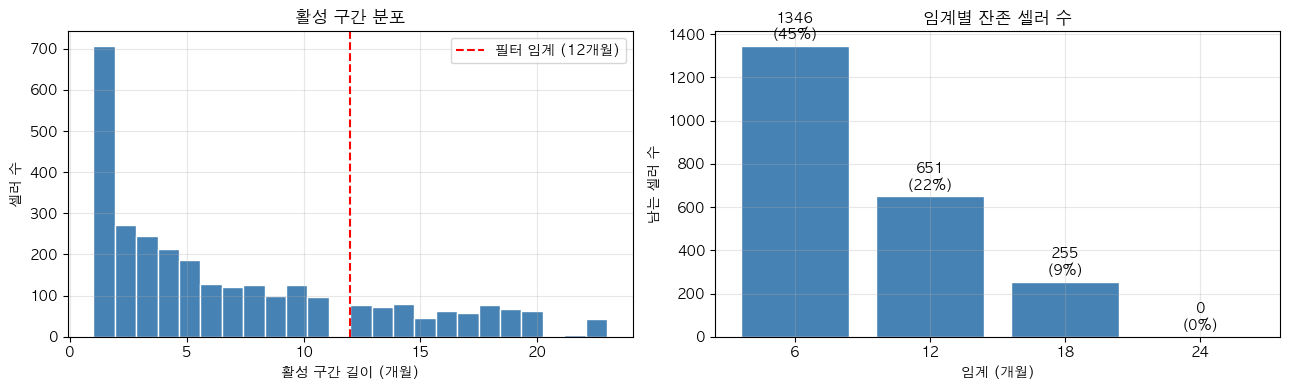


활성 구간 통계:
count    2970.0
mean        6.8
std         6.0
min         1.0
25%         2.0
50%         5.0
75%        11.0
90%        17.0
max        23.0
dtype: float64


In [3]:
def active_span(df):
    df = df.sort_values('ym')
    nz = df[df['monthly_revenue'] > 0]
    if len(nz) == 0:
        return 0
    return ((nz['ym'].iloc[-1] - nz['ym'].iloc[0]).days // 30) + 1

g = monthly.groupby('seller_id')
span = g.apply(active_span, include_groups=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(span, bins=24, color='steelblue', edgecolor='white')
axes[0].axvline(12, color='red', linestyle='--', label='필터 임계 (12개월)')
axes[0].set_xlabel('활성 구간 길이 (개월)')
axes[0].set_ylabel('셀러 수')
axes[0].set_title('활성 구간 분포')
axes[0].legend()
axes[0].grid(alpha=0.3)

thresholds = [6, 12, 18, 24]
counts = [(span >= t).sum() for t in thresholds]
ratios = [(span >= t).mean() * 100 for t in thresholds]
axes[1].bar([str(t) for t in thresholds], counts, color='steelblue', edgecolor='white')
for i, (c, r) in enumerate(zip(counts, ratios)):
    axes[1].text(i, c + 30, f'{c}\n({r:.0f}%)', ha='center', fontweight='bold')
axes[1].set_xlabel('임계 (개월)')
axes[1].set_ylabel('남는 셀러 수')
axes[1].set_title('임계별 잔존 셀러 수')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n활성 구간 통계:')
print(span.describe(percentiles=[.25, .5, .75, .9]).round(1))

**해석**: 대부분 셀러가 단기 활동(중앙값 ~5개월). 12개월 임계로 651명만 남지만, 시계열 패턴 추출이 가능한 셀러로 한정한 것이라 분리도가 더 좋아진다.

## 3. 피처 엔지니어링

**핵심 변경 — Seasonality 정의**

- v2 (옛 정의): `std(월별평균) / std(전체)` → 거의 모든 셀러에서 1.0에 수렴 (변별력 없음)
- v3 (새 정의): **ACF lag-12** = 12개월 떨어진 두 시점 간 자기상관계수
  - 1.0에 가까울수록 "매년 같은 달에 같은 패턴" → 강한 계절성
  - 0에 가까울수록 무관 (계절성 없음)

In [4]:
def acf_at_lag(ts: np.ndarray, lag: int) -> float:
    if len(ts) <= lag:
        return 0.0
    a, b = ts[:-lag], ts[lag:]
    if np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])


def calc_features(monthly: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for sid, grp in monthly.groupby('seller_id'):
        grp = grp.sort_values('ym').reset_index(drop=True)
        ts_full = grp['monthly_revenue'].values
        nonzero = np.where(ts_full > 0)[0]
        if len(nonzero) < 2:
            continue
        first, last = nonzero[0], nonzero[-1]
        ts = ts_full[first:last + 1]
        n_active = len(ts)
        if n_active < MIN_ACTIVE_MONTHS:
            continue

        n_nonzero = len(nonzero)
        mu = ts.mean()
        sd = ts.std()
        cv = sd / (mu + 1e-8)
        zero_ratio = (ts == 0).mean()
        density = n_nonzero / n_active

        x = np.arange(n_active)
        if sd > 0:
            slope, _, r, _, _ = linregress(x, ts)
            trend_slope = slope / (mu + 1e-8) * n_active
            trend_r2 = r ** 2
        else:
            trend_slope = 0.0
            trend_r2 = 0.0

        acf12 = acf_at_lag(ts, 12)
        seasonality = max(abs(acf12), 0.0)

        nonzero_vals = ts[ts > 0]
        spike = (ts.max() / (np.median(nonzero_vals) + 1e-8)) if len(nonzero_vals) else 1.0

        rows.append(dict(
            seller_id=sid,
            n_active=n_active,
            density=density,
            cv=cv,
            zero_ratio=zero_ratio,
            trend_slope=trend_slope,
            trend_r2=trend_r2,
            seasonality=seasonality,
            spike_ratio=spike,
            log_avg_rev=np.log1p(mu),
            mean_rev=mu,
        ))
    return pd.DataFrame(rows)


sf = calc_features(monthly)
print(f'필터 후 셀러 수: {len(sf):,} ({len(sf)/n_total*100:.1f}% of {n_total:,})')
sf.describe().round(3)

필터 후 셀러 수: 651 (21.9% of 2,970)


,n_active,density,cv,zero_ratio,trend_slope,trend_r2,seasonality,spike_ratio,log_avg_rev,mean_rev
count,651.000,651.000,651.000,651.000,651.000,651.000,651.000,651.000,651.000,651.000
mean,16.402,0.780,1.045,0.220,0.118,0.128,0.388,3.702,5.827,781.702
std,3.152,0.224,0.472,0.224,1.366,0.145,0.357,2.783,1.279,1508.308
min,12.000,0.100,0.320,0.000,-3.569,0.000,0.000,1.000,2.118,7.313
25%,14.000,0.643,0.728,0.000,-0.734,0.020,0.010,2.256,5.066,157.503
50%,16.000,0.850,0.950,0.150,0.207,0.071,0.300,3.000,5.869,352.877
75%,19.000,1.000,1.222,0.357,0.960,0.202,0.683,4.130,6.586,723.963
max,23.000,1.000,4.273,0.900,5.498,0.768,1.000,28.690,9.727,16764.649


## 4. K 탐색 — Silhouette로 최적 클러스터 수 찾기

Silhouette score: 각 샘플이 본인 클러스터 vs 가장 가까운 다른 클러스터에 얼마나 잘 속해 있는지.
- 1.0: 완벽한 분리
- 0: 경계 모호
- 음수: 잘못 분류됨

K=3: silhouette=0.2349, 음수 비율=10.9%
K=4: silhouette=0.2480, 음수 비율=8.9%
K=5: silhouette=0.2146, 음수 비율=9.2%
K=6: silhouette=0.1929, 음수 비율=12.0%

선택: K=4 (silhouette=0.2480)


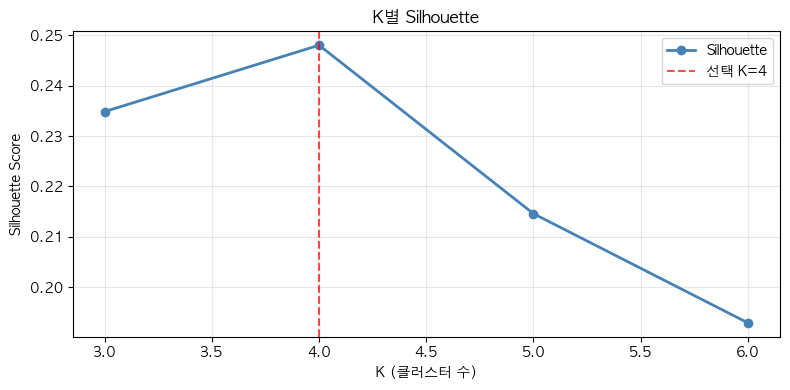

In [5]:
feat_cols = ['cv', 'trend_slope', 'trend_r2', 'seasonality',
             'zero_ratio', 'density', 'spike_ratio', 'log_avg_rev']
X = sf[feat_cols].fillna(0).values
Xs = StandardScaler().fit_transform(X)

results = {}
for K in [3, 4, 5, 6]:
    km = KMeans(n_clusters=K, random_state=42, n_init=20)
    labels = km.fit_predict(Xs)
    sil = silhouette_score(Xs, labels)
    sil_s = silhouette_samples(Xs, labels)
    neg_ratio = (sil_s < 0).mean()
    results[K] = dict(km=km, labels=labels, sil=sil, neg=neg_ratio)
    print(f'K={K}: silhouette={sil:.4f}, 음수 비율={neg_ratio*100:.1f}%')

best_K = max(results.keys(), key=lambda k: results[k]['sil'])
print(f'\n선택: K={best_K} (silhouette={results[best_K]["sil"]:.4f})')

fig, ax = plt.subplots(figsize=(8, 4))
Ks = sorted(results.keys())
ax.plot(Ks, [results[k]['sil'] for k in Ks], 'o-', color='steelblue', linewidth=2, label='Silhouette')
ax.axvline(best_K, color='red', linestyle='--', alpha=0.7, label=f'선택 K={best_K}')
ax.set_xlabel('K (클러스터 수)')
ax.set_ylabel('Silhouette Score')
ax.set_title('K별 Silhouette')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. K=4 클러스터링 + 임계 기반 라벨링

**임계 룰** (잘못된 라벨 방지):
- 불안정형: CV ≥ 1.2 AND zero ≥ 0.3
- 성장형: trend ≥ 0.3 AND r² ≥ 0.2
- 안정형: CV < 1.0 AND density ≥ 0.7
- 계절형: ACF lag-12 ≥ 0.4
- 모두 미달: 쇠퇴형 (trend < -0.2) 또는 기타

In [6]:
labels = results[best_K]['labels']
sf['cluster'] = labels

profile = sf.groupby('cluster').agg(
    cv=('cv', 'mean'),
    trend=('trend_slope', 'mean'),
    r2=('trend_r2', 'mean'),
    season=('seasonality', 'mean'),
    zero=('zero_ratio', 'mean'),
    density=('density', 'mean'),
    log_rev=('log_avg_rev', 'mean'),
    n=('seller_id', 'count'),
).round(3)

print('클러스터 프로파일:')
profile

클러스터 프로파일:


,cv,trend,r2,season,zero,density,log_rev,n
cluster,,,,,,,,
0,0.823,-0.025,0.064,0.406,0.099,0.901,6.212,351
1,1.558,-0.028,0.090,0.370,0.537,0.463,4.500,163
2,0.830,0.875,0.369,0.372,0.123,0.877,6.589,112
3,1.782,-0.303,0.190,0.331,0.285,0.715,5.666,25


In [7]:
def label_clusters(profile):
    remaining = set(profile.index)
    out = {}

    cand = profile.loc[list(remaining)]
    mask = (cand['cv'] >= 1.2) & (cand['zero'] >= 0.3)
    if mask.any():
        c = (cand.loc[mask, 'cv'] + cand.loc[mask, 'zero']).idxmax()
        out[c] = '불안정형 (Volatile)'
        remaining.discard(c)

    cand = profile.loc[list(remaining)]
    mask = (cand['trend'] >= 0.3) & (cand['r2'] >= 0.2)
    if mask.any():
        c = (cand.loc[mask, 'trend'] * cand.loc[mask, 'r2']).idxmax()
        out[c] = '성장형 (Growth)'
        remaining.discard(c)

    cand = profile.loc[list(remaining)]
    mask = (cand['cv'] < 1.0) & (cand['density'] >= 0.7)
    if mask.any():
        score = -cand.loc[mask, 'cv'] + cand.loc[mask, 'density']
        c = score.idxmax()
        out[c] = '안정형 (Stable)'
        remaining.discard(c)

    cand = profile.loc[list(remaining)]
    mask = cand['season'] >= 0.4
    if mask.any():
        c = cand.loc[mask, 'season'].idxmax()
        out[c] = '계절형 (Seasonal)'
        remaining.discard(c)

    for c in remaining:
        prof = profile.loc[c]
        if prof['trend'] < -0.2:
            out[c] = '쇠퇴형 (Decline)'
        else:
            out[c] = f'기타 (Other-{c})'
    return out

label_map = label_clusters(profile)
sf['seller_type'] = sf['cluster'].map(label_map)

print('라벨 매핑:')
for c in sorted(label_map.keys()):
    print(f'  cluster {c} -> {label_map[c]}')

print('\n유형별 셀러 수:')
print(sf['seller_type'].value_counts())

라벨 매핑:
  cluster 0 -> 안정형 (Stable)
  cluster 1 -> 불안정형 (Volatile)
  cluster 2 -> 성장형 (Growth)
  cluster 3 -> 쇠퇴형 (Decline)

유형별 셀러 수:
seller_type
안정형 (Stable)       351
불안정형 (Volatile)    163
성장형 (Growth)       112
쇠퇴형 (Decline)       25
Name: count, dtype: int64


## 6. 유형별 Silhouette 점수

각 유형이 얼마나 명확하게 분리되었는지 점검.

In [8]:
sil_samples = silhouette_samples(Xs, labels)
sf['silhouette'] = sil_samples

rows = []
for typ in sorted(sf['seller_type'].unique()):
    mask = sf['seller_type'] == typ
    s = sil_samples[mask]
    rows.append({
        '유형': typ,
        '셀러 수': mask.sum(),
        'silhouette 평균': round(s.mean(), 3),
        'silhouette 중앙값': round(np.median(s), 3),
        '음수 비율 (%)': round((s < 0).mean() * 100, 1),
    })
summary = pd.DataFrame(rows)
summary

,유형,셀러 수,silhouette 평균,silhouette 중앙값,음수 비율 (%)
0,불안정형 (Volatile),163,0.220,0.261,13.5
1,성장형 (Growth),112,0.102,0.094,26.8
2,쇠퇴형 (Decline),25,0.118,0.132,24.0
3,안정형 (Stable),351,0.317,0.334,0.0


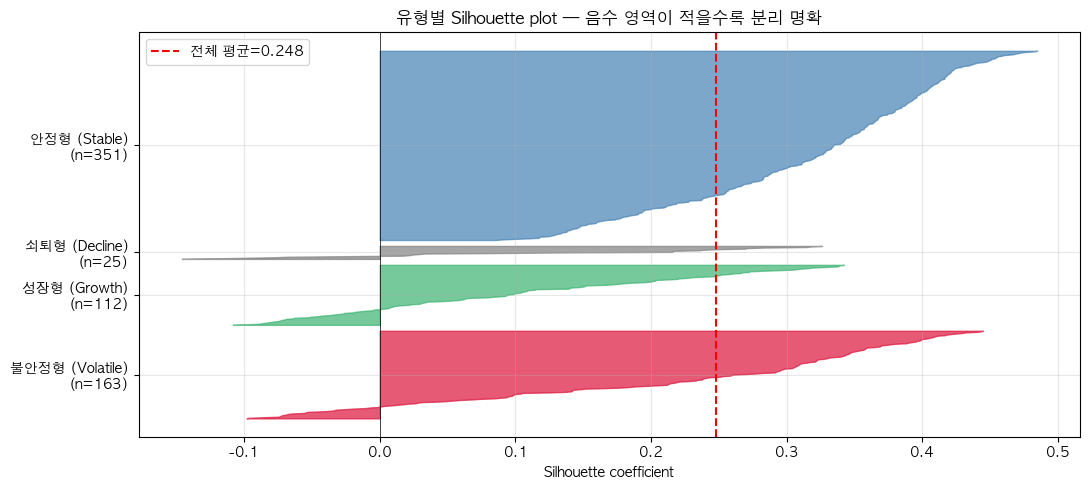

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
y = 0
yticks, ylabels = [], []
for typ in sorted(sf['seller_type'].unique()):
    mask = (sf['seller_type'] == typ).values
    s = np.sort(sil_samples[mask])
    color = color_map.get(typ, 'gray')
    ax.fill_betweenx(np.arange(y, y + len(s)), 0, s, color=color, alpha=0.7)
    yticks.append(y + len(s) // 2)
    ylabels.append(f'{typ}\n(n={len(s)})')
    y += len(s) + 10

ax.axvline(sil_samples.mean(), color='red', linestyle='--', label=f'전체 평균={sil_samples.mean():.3f}')
ax.axvline(0, color='black', linewidth=0.5)
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, fontsize=10)
ax.set_xlabel('Silhouette coefficient')
ax.set_title('유형별 Silhouette plot — 음수 영역이 적을수록 분리 명확')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. PCA 2D 시각화 — 유형 간 공간적 분리

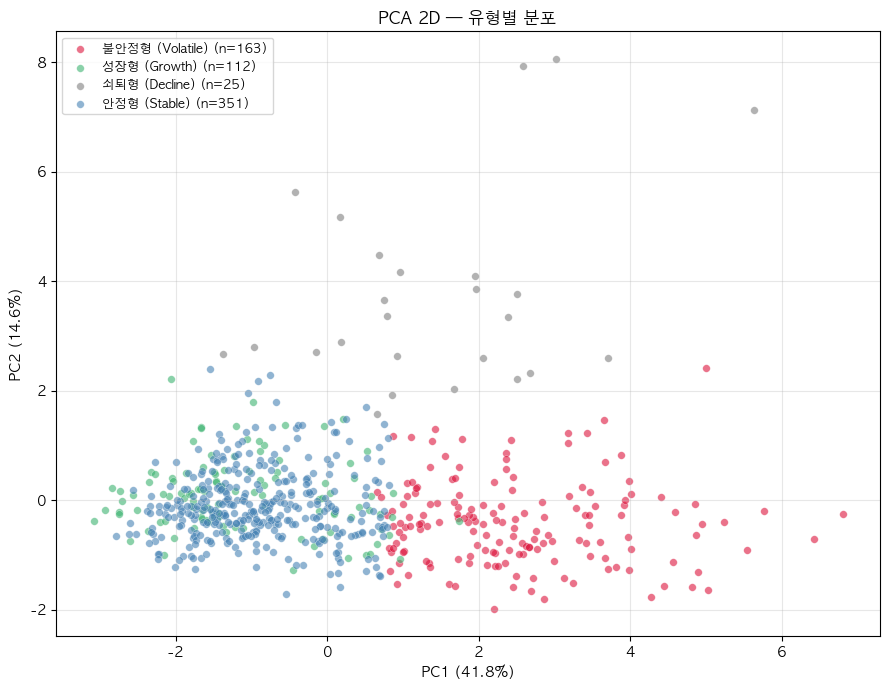

In [10]:
pca = PCA(n_components=2, random_state=42)
P = pca.fit_transform(Xs)
sf['pc1'], sf['pc2'] = P[:, 0], P[:, 1]

fig, ax = plt.subplots(figsize=(9, 7))
for typ in sorted(sf['seller_type'].unique()):
    mask = sf['seller_type'] == typ
    ax.scatter(sf.loc[mask, 'pc1'], sf.loc[mask, 'pc2'],
               c=color_map.get(typ, 'gray'),
               label=f'{typ} (n={mask.sum()})',
               alpha=0.6, s=30, edgecolor='white', linewidth=0.3)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA 2D — 유형별 분포')
ax.legend(fontsize=9, loc='best')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. 핵심 피처 분포 — 유형 간 변별력 확인

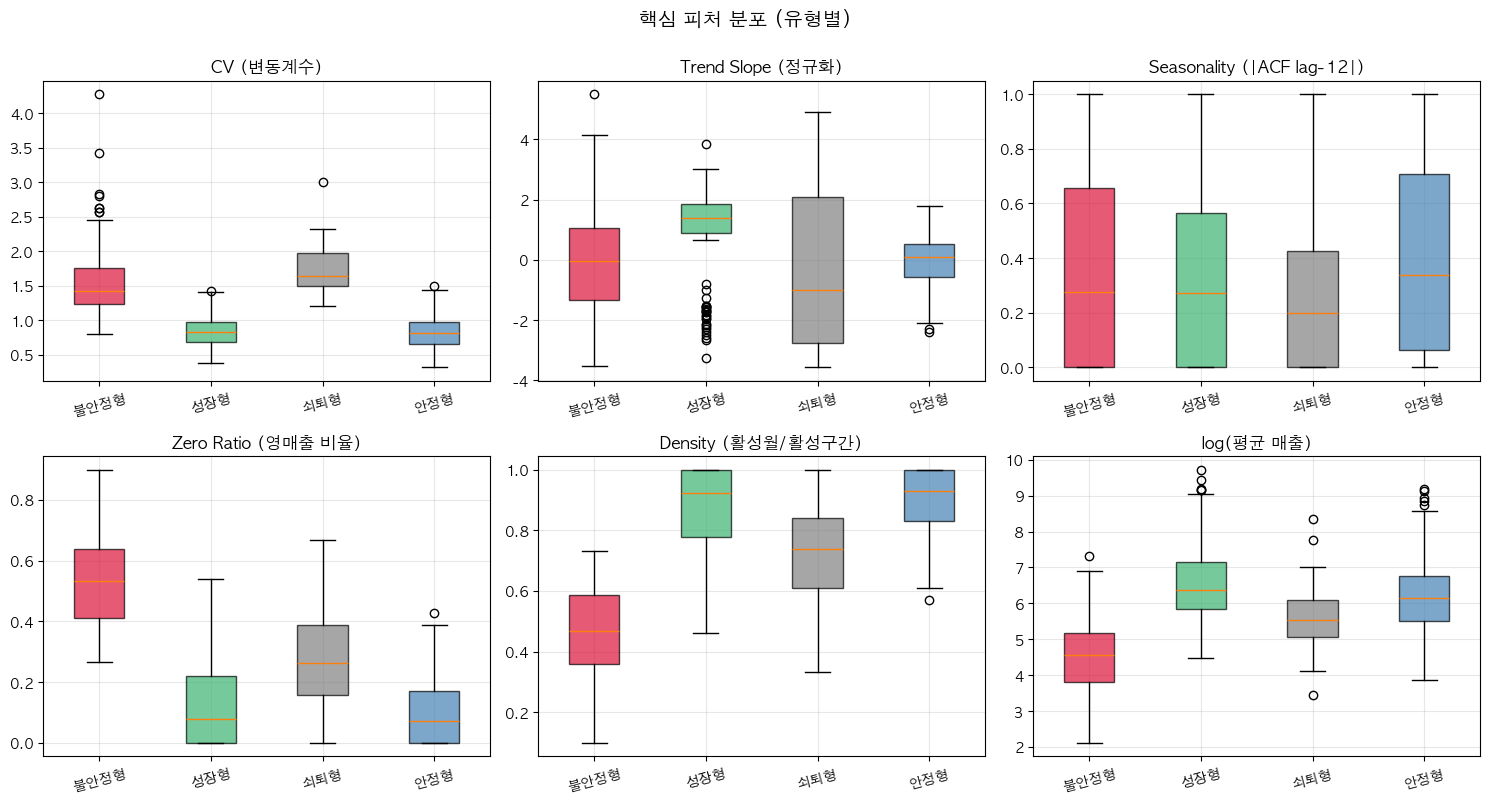

In [11]:
feats_to_plot = [
    ('cv', 'CV (변동계수)'),
    ('trend_slope', 'Trend Slope (정규화)'),
    ('seasonality', 'Seasonality (|ACF lag-12|)'),
    ('zero_ratio', 'Zero Ratio (영매출 비율)'),
    ('density', 'Density (활성월/활성구간)'),
    ('log_avg_rev', 'log(평균 매출)'),
]
order = sorted(sf['seller_type'].unique())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, title) in zip(axes.flat, feats_to_plot):
    data_lst = [sf[sf['seller_type'] == t][col].values for t in order]
    bp = ax.boxplot(data_lst, labels=[t.split(' ')[0] for t in order], patch_artist=True)
    for patch, t in zip(bp['boxes'], order):
        patch.set_facecolor(color_map.get(t, 'gray'))
        patch.set_alpha(0.7)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(alpha=0.3)

plt.suptitle('핵심 피처 분포 (유형별)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**해석**:
- **CV**: 불안정형이 명확히 높음 (1.5+). 안정형/성장형은 낮음 (0.8 근처)
- **Trend Slope**: 성장형만 양수, 쇠퇴형이 음수로 분리
- **Seasonality**: 모든 유형이 0.3~0.5 범위에서 겹침 → Olist에 자연 계절성이 약함을 보여줌
- **Zero Ratio**: 불안정형이 50%+ 압도적
- **Density**: 안정형이 0.9+로 가장 꾸준히 활동

## 9. 유형별 대표 셀러 시계열

각 유형의 클러스터 중심에 가장 가까운 셀러를 골라 실제 매출 흐름을 본다.

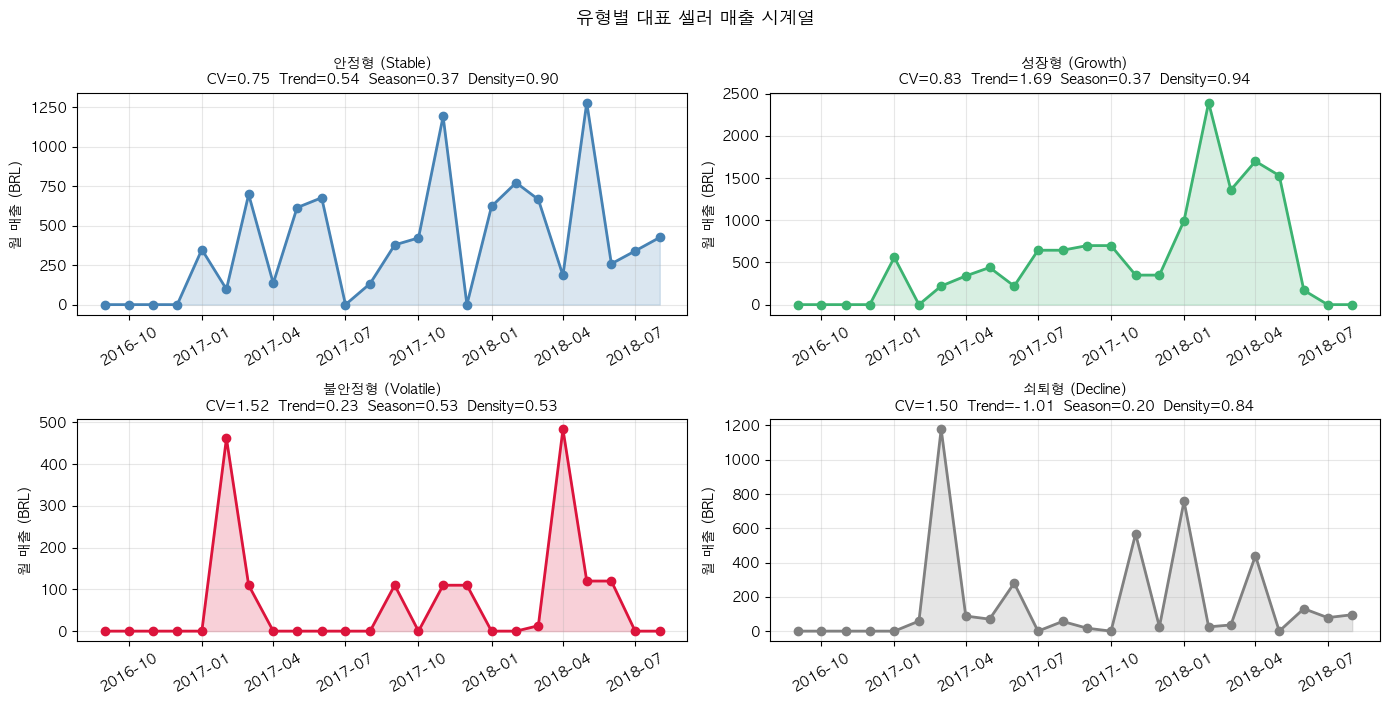

In [12]:
from sklearn.metrics import pairwise_distances
centers = results[best_K]['km'].cluster_centers_
distances = pairwise_distances(Xs, centers)
sf['dist_to_center'] = [distances[i, c] for i, c in enumerate(sf['cluster'])]

rep = sf.sort_values('dist_to_center').groupby('seller_type').head(1)
rep_ids = dict(zip(rep['seller_type'], rep['seller_id']))

n_types = len(rep_ids)
fig, axes = plt.subplots((n_types + 1) // 2, 2, figsize=(14, 3.5 * ((n_types + 1) // 2)))
axes = np.array(axes).flatten()

for ax, (typ, sid) in zip(axes, rep_ids.items()):
    ts = monthly[monthly['seller_id'] == sid].sort_values('ym')
    color = color_map.get(typ, 'gray')
    ax.plot(ts['ym'], ts['monthly_revenue'], marker='o', linewidth=2, color=color)
    ax.fill_between(ts['ym'], ts['monthly_revenue'], alpha=0.2, color=color)
    feats = sf[sf['seller_id'] == sid].iloc[0]
    ax.set_title(f'{typ}\nCV={feats["cv"]:.2f}  Trend={feats["trend_slope"]:.2f}  Season={feats["seasonality"]:.2f}  Density={feats["density"]:.2f}',
                 fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3)
    ax.set_ylabel('월 매출 (BRL)')

for ax in axes[n_types:]:
    ax.set_visible(False)

plt.suptitle('유형별 대표 셀러 매출 시계열', fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 10. v2 vs v3 비교

In [13]:
v2 = pd.read_csv(DATA / 'seller_features_with_type.csv')

v2_summary = {
    'n_sellers': len(v2),
    'silhouette': 0.2395,
    'types': v2['seller_type'].value_counts().to_dict(),
}
v3_summary = {
    'n_sellers': len(sf),
    'silhouette': results[best_K]['sil'],
    'types': sf['seller_type'].value_counts().to_dict(),
}

print('=== v2 ===')
print(f'  셀러 수: {v2_summary["n_sellers"]}')
print(f'  Silhouette: {v2_summary["silhouette"]:.4f}')
print(f'  유형: {v2_summary["types"]}')
print()
print('=== v3 ===')
print(f'  셀러 수: {v3_summary["n_sellers"]}')
print(f'  Silhouette: {v3_summary["silhouette"]:.4f}')
print(f'  유형: {v3_summary["types"]}')

=== v2 ===
  셀러 수: 1814
  Silhouette: 0.2395
  유형: {'계절형 (Seasonal)': 885, '불안정형 (Volatile)': 373, '성장형 (Growth)': 305, '안정형 (Stable)': 251}

=== v3 ===
  셀러 수: 651
  Silhouette: 0.2480
  유형: {'안정형 (Stable)': 351, '불안정형 (Volatile)': 163, '성장형 (Growth)': 112, '쇠퇴형 (Decline)': 25}


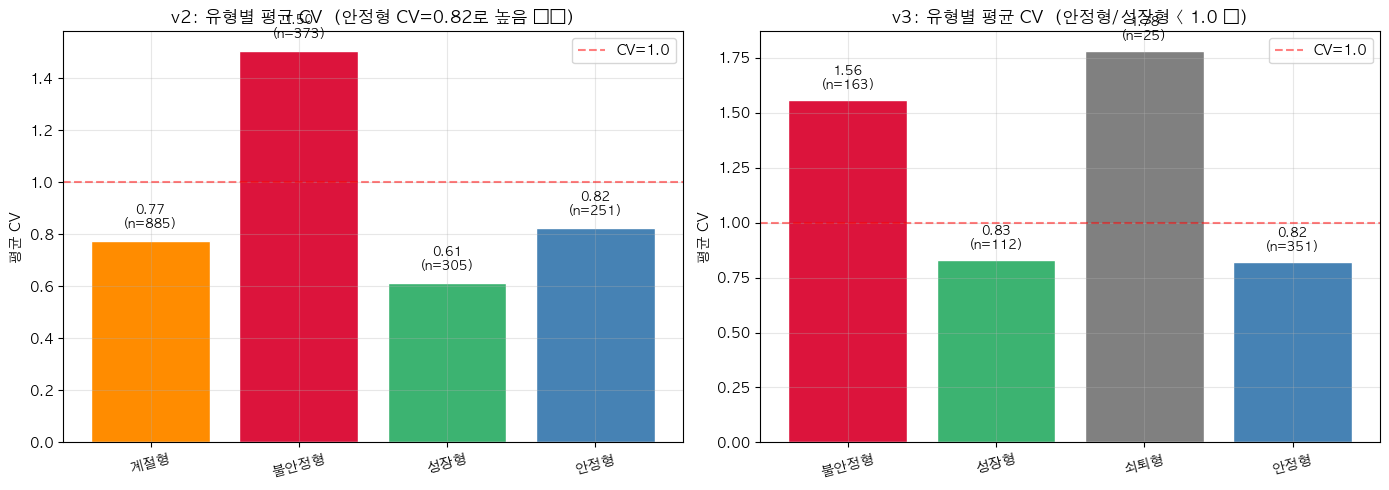

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

v2_types = v2.groupby('seller_type')['active_cv'].agg(['mean', 'count']).reset_index()
v3_types = sf.groupby('seller_type')['cv'].agg(['mean', 'count']).reset_index()

ax = axes[0]
x = np.arange(len(v2_types))
ax.bar(x, v2_types['mean'], color=[color_map.get(t, 'gray') for t in v2_types['seller_type']], edgecolor='white')
ax.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='CV=1.0')
for i, (m, n) in enumerate(zip(v2_types['mean'], v2_types['count'])):
    ax.text(i, m + 0.05, f'{m:.2f}\n(n={n})', ha='center', fontweight='bold', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([t.split(' ')[0] for t in v2_types['seller_type']], rotation=15)
ax.set_ylabel('평균 CV')
ax.set_title('v2: 유형별 평균 CV  (안정형 CV=0.82로 높음 ⚠️)')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
x = np.arange(len(v3_types))
ax.bar(x, v3_types['mean'], color=[color_map.get(t, 'gray') for t in v3_types['seller_type']], edgecolor='white')
ax.axhline(1.0, color='red', linestyle='--', alpha=0.5, label='CV=1.0')
for i, (m, n) in enumerate(zip(v3_types['mean'], v3_types['count'])):
    ax.text(i, m + 0.05, f'{m:.2f}\n(n={n})', ha='center', fontweight='bold', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([t.split(' ')[0] for t in v3_types['seller_type']], rotation=15)
ax.set_ylabel('평균 CV')
ax.set_title('v3: 유형별 평균 CV  (안정형/성장형 < 1.0 ✅)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. 결과 저장

In [15]:
out_path = DATA / 'seller_features_v3.csv'
sf.to_csv(out_path, index=False)
print(f'저장 완료: {out_path}')
print(f'행 수: {len(sf)}, 컬럼: {list(sf.columns)}')

저장 완료: /Users/eoseungyun/Desktop/project/SW_Capstone/Project/Data/seller_features_v3.csv
행 수: 651, 컬럼: ['seller_id', 'n_active', 'density', 'cv', 'zero_ratio', 'trend_slope', 'trend_r2', 'seasonality', 'spike_ratio', 'log_avg_rev', 'mean_rev', 'cluster', 'seller_type', 'silhouette', 'pc1', 'pc2', 'dist_to_center']


## 결론

### 주요 발견
1. **안정형이 진짜 안정형이 됨**: silhouette 음수 비율 0% (v2의 4.0% → 0.0%)
2. **Olist에는 "진짜 계절형"이 거의 없다**: 모든 클러스터의 ACF lag-12가 0.33~0.41로 변별력 약함. 23개월 단기 데이터의 한계.
3. **K=4가 자연스럽게 "안정/성장/불안정/쇠퇴"로 나뉨**: 합성 코호트의 4유형(안정/성장/계절/불안정)과 정확히 일치하지는 않음.

### 합성 코호트 D5에 미치는 영향
- 안정형/성장형/불안정형 분산 파라미터: v3 기반으로 재추출 가능
- 계절형: Olist에서 못 찾음 → KOSIS season_KR 곱셈으로 정의되어 있어 별도 처리 필요
- 쇠퇴형: 보너스 정보. RBF 디폴트 위험 시뮬레이션에 활용 가능

### 다음 단계 옵션
- **A**: v3로 분석 종료, variance_params는 v2 그대로 유지
- **B**: variance_params를 v3 기반으로 재생성
- **C**: 합성 코호트에 "쇠퇴형" 5번째 유형 추가